In [10]:
# Importing necessary packages
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib import colors as mcolors
from matplotlib import patches as mpatches
from matplotlib.colors import LogNorm
from PIL import Image
from scipy.ndimage import zoom
from matplotlib.colors import LinearSegmentedColormap
from scipy.ndimage import gaussian_filter1d

# Setting high resolution figures for the presentation
plt.rcParams['figure.dpi'] = 150

In [11]:
# Loading data for figure 1
data = pd.read_csv('Large et al 2007.csv')
# Means spreadsheet was arranged in in reverse order than what I needed, so I made the correct one a reversed version of that
means_reversed = pd.read_csv('Large et al 2007 Means.csv')
means = means_reversed[::-1]
# Loading data for figure 2
data2 = pd.read_csv('Data Combined.csv')

In [12]:
# Defining variables used for both figures
# Figure 1:
s_type = data['Sulfide type']
au = data['Au (ppm)']
ars = data['As (ppm)']
au_mean = means['Au (ppm)']
ars_mean = means['As (ppm)']
s_type_mean = means['Sulfide type']
n_vals = means['n']
# Figure 2:
au2 = data2['Au (ppm)']
ars2 = data2['As (ppm)']
paper = data2['Paper']
dep = data2['Deposit']

Text(1, -0.65, '')

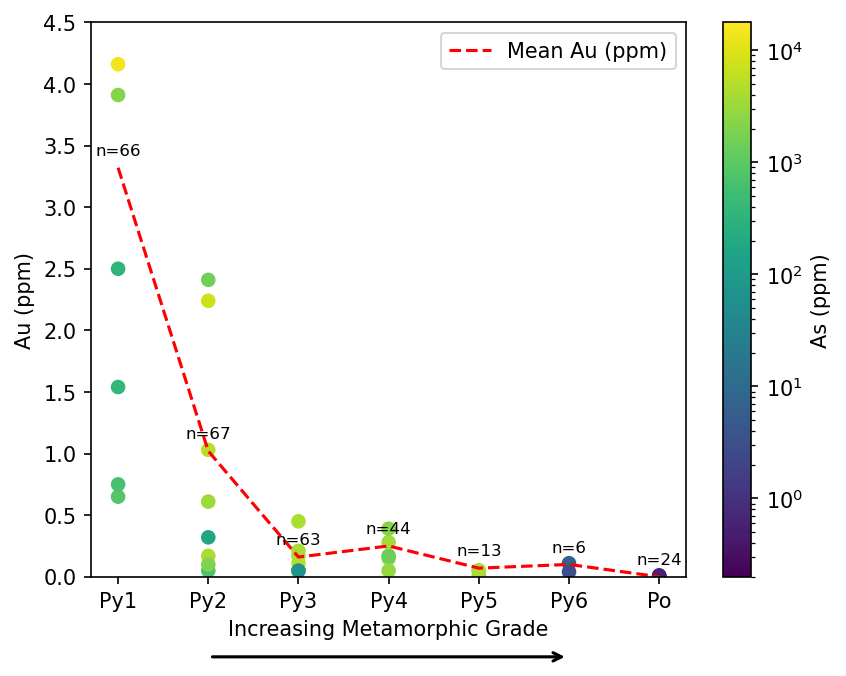

In [13]:
# Norm making the Ars scale logarithmic
norm = LogNorm(vmin=np.min(ars),vmax=np.max(ars))

# Masking out categories that are not relevant to my data
mask2 = ~np.isin(s_type_mean,['Asp','Matrix'])

# Scatter with categorial sulfide types on the x-axis and amount of gold on the y-axis, with colour representing the amount of arsenic
plt.scatter(s_type,au,c=ars,norm=norm)

# Line representing the means, this was used instead of regression due to having a categorical x-axis
plt.plot(np.array(s_type_mean)[mask2],
         np.array(au_mean)[mask2],
         'r--',
         label='Mean Au (ppm)')

# Adding the n-value for the means calculated (not all data used for the means were included by the author in the public dataset)
for x, y, n in zip(np.array(s_type_mean)[mask2],np.array(au_mean)[mask2],np.array(n_vals)[mask2]):
    plt.text(x,y+0.1,'n=%s'%(n),ha='center',fontsize=8)
    
# Other graph design features
plt.ylim(0,4.5)
plt.xlabel('Increasing Metamorphic Grade')
plt.ylabel('Au (ppm)')
plt.colorbar(label='As (ppm)')
plt.legend()

# Adding arrow underneath the x-label
plt.annotate('',xy=(5,-0.65), xytext=(1, -0.65), arrowprops=dict(facecolor='black', arrowstyle='->', lw=1.5),
            annotation_clip=False)


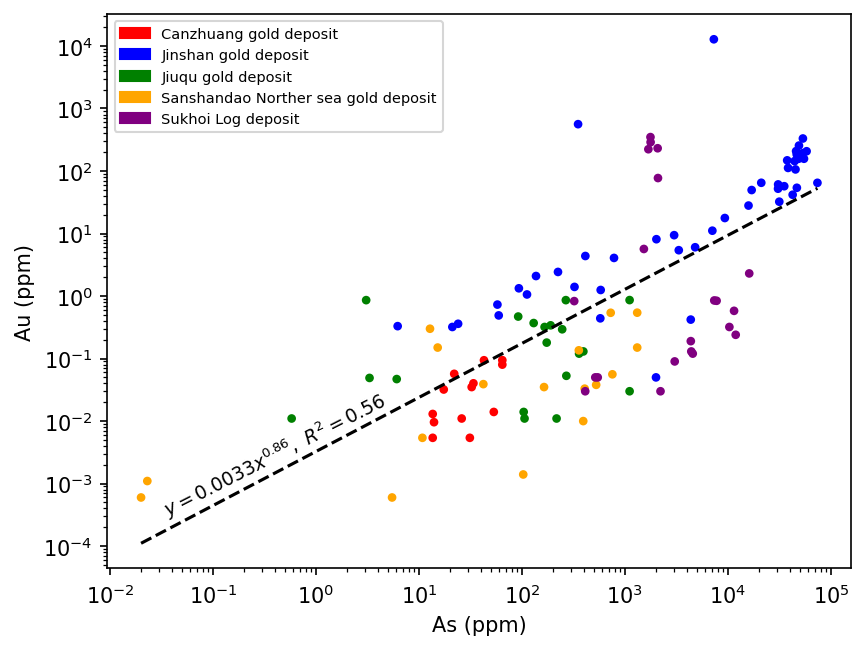

In [14]:
# Colour dictionary for the different deposit types
deps = np.unique(dep)
color_dict = {deps[0]:'red', deps[1]:'blue', deps[2]:'green', deps[3]:'orange', deps[4]:'purple'}
# Scatter plot of arsenic vs gold, color depending on deposit as defined by dictionary
plt.scatter(ars2,au2,
    color=[color_dict[i] for i in dep],
    s=10)
# Other features, x- and y-scale as log
plt.xlabel('As (ppm)')
plt.xscale('log')
plt.yscale('log')
plt.ylabel('Au (ppm)')

# Ensuring there are no non-finite numbers
mask = (np.isfinite(ars2) & np.isfinite(au2) & (ars2 > 0) & (au2 > 0))
ars_fin = ars2[mask]
au_fin = au2[mask]
logx = np.log10(ars_fin)
logy = np.log10(au_fin)

# Polyfit to make get a linear regression from the log plot
polyfit = np.polyfit(logx, logy, 1)
tempx = np.linspace(np.min(logx), np.max(logx), 100)
tempy = np.polyval(polyfit, tempx)
# Polyfit plotted as a power of 10 due to being in log scale
plt.plot(10**tempx, 10**tempy, 'k--')

# Calculating r2 value
logy_pred = np.polyval(polyfit, logx)
ss_res = np.sum((logy - logy_pred)**2)
ss_tot = np.sum((logy - np.mean(logy))**2)
r2 = 1 - ss_res / ss_tot

# Text for the regression line
a = 10**polyfit[1]
b = polyfit[0]
plt.text(0.03,0.0003,f"$y = {a:.2}x^{{{b:.2f}}},\\ R^2 = {r2:.2f}$",
         fontsize=9, rotation=27)

# Legend defined by the colour dictionary
handles = [mpatches.Patch(color=color_dict[k], label=k) for k in color_dict]
plt.legend(handles=handles,fontsize=7,loc='upper left')

In [15]:
# Loading image for figure 3
img = Image.open('Hastie et al 2020.png').convert('RGB')
img = np.array(img)

# Cropping image map
map_img = img[40:-60, 40:int(img.shape[1]*0.85)-40, :]
map_h, map_w, _ = map_img.shape
# Upsampling map for higher resolution
upsample_factor = 2
map_img_hr = zoom(map_img, (upsample_factor, upsample_factor, 1), order=1)
map_h_hr, map_w_hr, _ = map_img_hr.shape

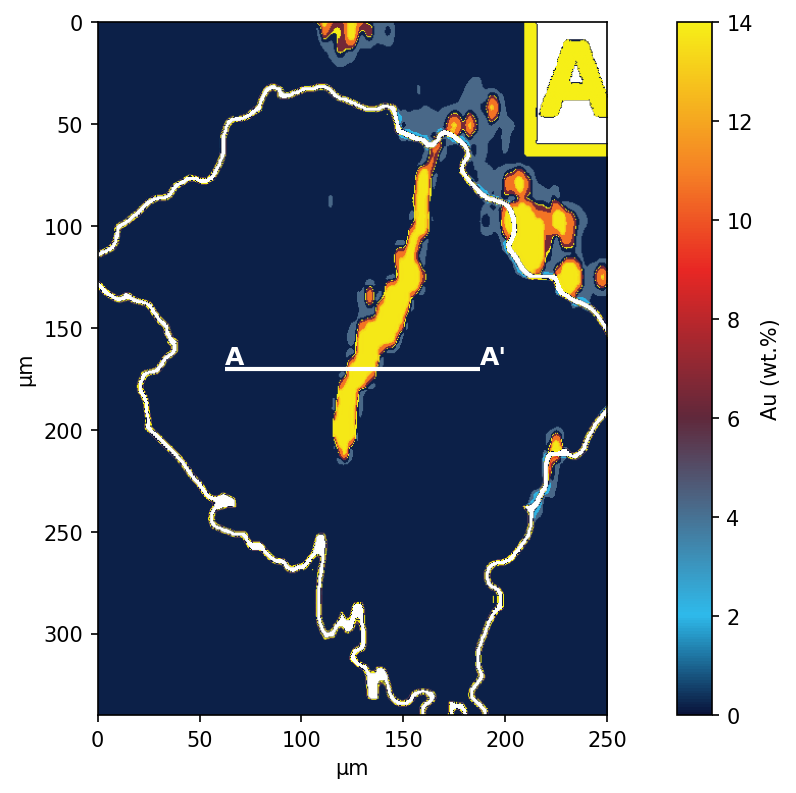

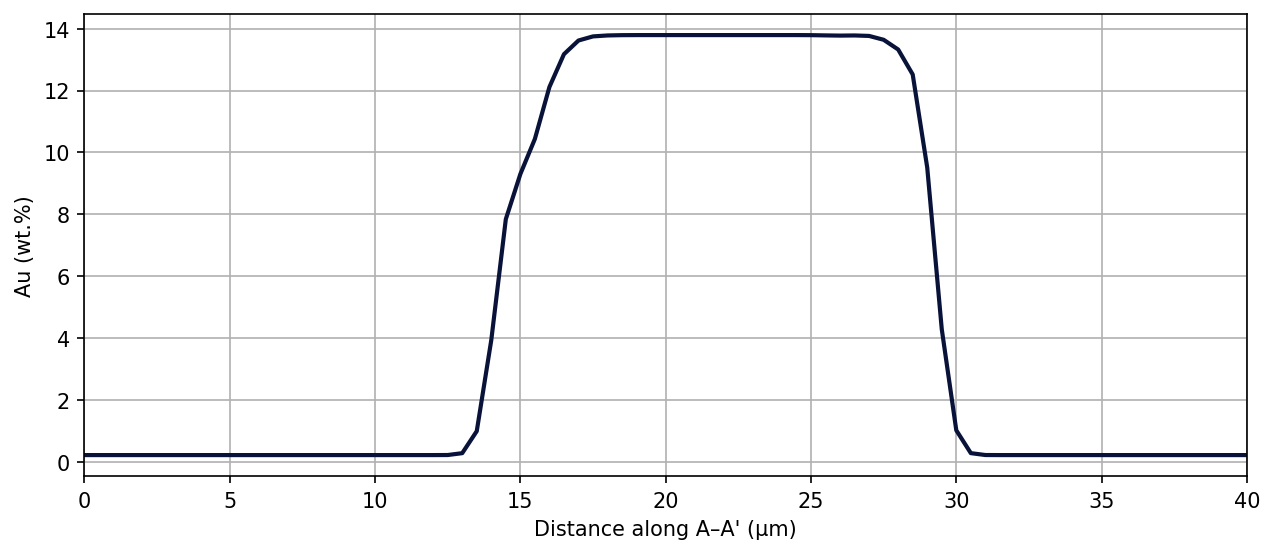

In [16]:
# Extract colorbar gradient
colorbar = img[:, int(img.shape[1]*0.85):, :]
mask = np.linalg.norm(colorbar - [255,255,255], axis=2) > 30
rows_with_color = np.any(mask, axis=1)
top_row = np.argmax(rows_with_color)
bottom_row = len(rows_with_color) - np.argmax(rows_with_color[::-1]) - 1
cb_colors = np.mean(colorbar[top_row:bottom_row+1, :, :], axis=1)[::-1]

# Define colorbar values (red ~9)
n = len(cb_colors)
red_index = n // 2
cb_values = np.linspace(0, 14, n)
shift = 9 - cb_values[red_index]
cb_values = np.clip(cb_values + shift, 0, 14)

# Map function
def color_to_value(rgb):
    dists = np.linalg.norm(cb_colors - rgb, axis=1)
    idx = np.argmin(dists)
    return cb_values[idx]

# Convert map to values
map_values_hr = np.zeros((map_h_hr, map_w_hr))
for i in range(map_h_hr):
    for j in range(map_w_hr):
        if np.linalg.norm(map_img_hr[i,j] - [255,255,255]) > 30:
            map_values_hr[i,j] = color_to_value(map_img_hr[i,j])
        else:
            map_values_hr[i,j] = np.nan

# Normalize 0–14
min_val = np.nanmin(map_values_hr)
max_val = np.nanmax(map_values_hr)
map_values_hr = (map_values_hr - min_val) / (max_val - min_val) * 14

# Custom colormap matching original image
colors = ["#09133a", "#2ebaeb", "#60283b", "#e82724", "#f58125", "#f6ef17"]
values_cmap = [0, 2, 6, 9, 11, 14]  # positions in wt.%

# Normalize positions 0-1 for LinearSegmentedColormap
positions = [(v-0)/(14-0) for v in values_cmap]
custom_cmap = LinearSegmentedColormap.from_list("original_colors", list(zip(positions, colors)))

# Cross-section line coordinates
y_cross = map_h_hr // 2
start_x = map_w_hr // 4
end_x   = map_w_hr * 3 // 4
cross_values = map_values_hr[y_cross, start_x:end_x+1]
cross_x_um = np.arange(start_x, end_x+1) / 2  # 2 pixels = 1 µm

# Plot Map
plt.figure(figsize=(12,6))
im = plt.imshow(map_values_hr, cmap=custom_cmap, origin='upper', 
                extent=[0, map_w_hr/2, map_h_hr/2, 0], vmin=0, vmax=14)
plt.colorbar(im, label='Au (wt.%)')
plt.hlines(y=y_cross/2, xmin=start_x/2, xmax=end_x/2, colors='white', linewidth=2)
plt.text(start_x/2, y_cross/2-2, "A", color='white', fontsize=12, weight='bold')
plt.text(end_x/2, y_cross/2-2, "A'", color='white', fontsize=12, weight='bold')
plt.xlabel("µm")
plt.ylabel("µm")
plt.show()

# Smooth the cross-section for plotting
cross_values_smooth = gaussian_filter1d(cross_values, sigma=1)

# Zoom in around peak
peak_idx = np.argmax(cross_values_smooth)
zoom_range = 40  # pixels (~20 µm)
start_idx = max(0, peak_idx - zoom_range)
end_idx = min(len(cross_values_smooth)-1, peak_idx + zoom_range)
zoom_x_um = cross_x_um[start_idx:end_idx+1] - cross_x_um[start_idx]  # shift x-axis to start at 0
zoom_vals = cross_values_smooth[start_idx:end_idx+1]

# Plot smoothed cross-section
plt.figure(figsize=(10,4))
plt.plot(zoom_x_um, zoom_vals, color='#09133a', linewidth=2)
plt.xlabel("Distance along A–A' (µm)")
plt.ylabel("Au (wt.%)")
plt.grid(True)
plt.xlim(0, zoom_x_um[-1])
plt.show()

# A on top right corner could not be cropped from original image but is overlain in the final graphic, ignore the color analysis of it as it does not correlate to Au wt%